In [14]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

In [15]:
np.random.seed(42)

n_clean = 140
x_clean = np.random.uniform(0 , 10 , n_clean)
true_slope , true_intercept = 2.5 , 5.0
noise_sd = 1.6
y_clean = true_intercept + true_slope * x_clean + np.random.normal(0 , noise_sd , n_clean)

n_out = 5
x_out = np.array([12.0 , 12.8 , 13.4 , 14.0 , 14.5])
y_out = np.array([60.0 , 65.0 , 70.0 , 75.0 , 80.0])

x_all = np.concatenate([x_clean , x_out])
y_all = np.concatenate([y_clean , y_out])

In [16]:
def ols_fit(x , y):
    X = np.column_stack([np.ones_like(x) , x])
    beta = np.linalg.lstsq(X , y , rcond = None)[0]
    yhat = X @ beta
    resid = y - yhat
    n , p = X.shape
    s2 = np.sum(resid ** 2) / (n - p)
    XtX_inv = np.linalg.inv(X.T @ X)
    H = X @ XtX_inv @ X.T
    h = np.diag(H)

    denom = np.sqrt(np.maximum(s2 , 1e-12) * np.maximum(1 - h , 1e-12))
    r_std = resid / denom

    cooks = (resid ** 2 / (p * np.maximum(s2 , 1e-12))) * (h / np.maximum((1 - h) ** 2 , 1e-12))

    return {
        "beta": beta , "yhat": yhat , "resid": resid ,
        "s2": s2 , "h": h , "r_std": r_std , "cooks": cooks
    }

In [17]:
fit_clean = ols_fit(x_clean , y_clean)
fit_all = ols_fit(x_all , y_all)
k = 5
top_idx = np.argsort(fit_all["cooks"])[-k : ][::-1]
n_all = len(x_all)
p = 2
lev_thr = 2 * p / n_all

Text(0.5, 1.0, 'How High-Leverage Outliers Can Drag an OLS Line')

Text(0.5, 0, 'X')

Text(0, 0.5, 'y')

Text(8.2, 66, 'Outliers are far in X →\nsmall count , big influence')

Text(0.02, 0.9, 'Slope (clean): +2.54   |   Slope (with outliers): +3.36')

...

Text(0.5, 1.0, 'Influence Map (size ≈ influence)')

Text(0.5, 0, 'Leverage (how unusual X is)')

Text(0, 0.5, 'Standardized residual (how wrong y is)')

Text(0.02, 0.92, 'Bigger bubbles = more influence\n(think: points that can move the line)')

/tmp/ipython-input-445/2652506471.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


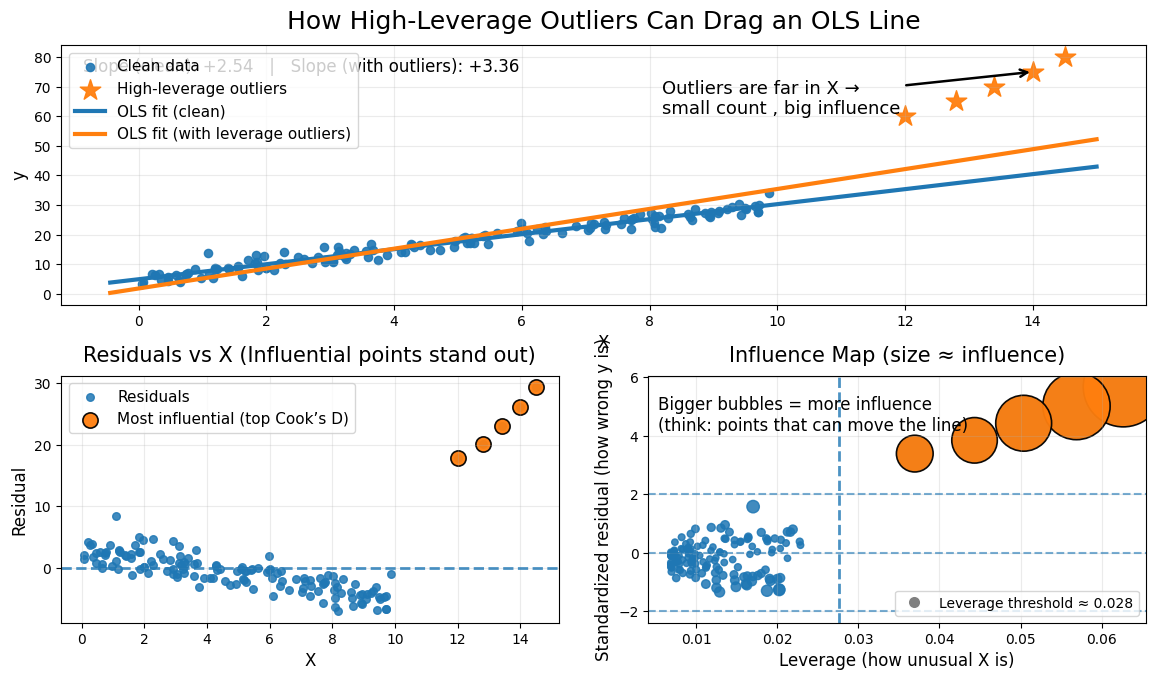

In [18]:
fig = plt.figure(figsize = (14 , 7.5))
gs = GridSpec(2 , 2 , figure = fig , height_ratios = [1.05 , 1.0] , hspace = 0.28 , wspace = 0.18)

ax1 = fig.add_subplot(gs[0 , :])
ax2 = fig.add_subplot(gs[1 , 0])
ax3 = fig.add_subplot(gs[1 , 1])

x_grid = np.linspace(min(x_all) - 0.5 , max(x_all) + 0.5 , 300)

ax1.scatter(x_clean , y_clean , s = 35 , alpha = 0.9 , label = "Clean data")
ax1.scatter(x_out , y_out , s = 240 , marker = "*" , alpha = 0.95 , label = "High-leverage outliers")
b0_c , b1_c = fit_clean["beta"]
b0_a , b1_a = fit_all["beta"]
ax1.plot(x_grid , b0_c + b1_c * x_grid , linewidth = 3 , label = "OLS fit (clean)")
ax1.plot(x_grid , b0_a + b1_a * x_grid , linewidth = 3 , label = "OLS fit (with leverage outliers)")
ax1.set_title("How High-Leverage Outliers Can Drag an OLS Line" , fontsize = 18 , pad = 12)
ax1.set_xlabel("X" , fontsize = 12)
ax1.set_ylabel("y" , fontsize = 12)
ax1.grid(True , alpha = 0.25)
ax1.annotate(
    "Outliers are far in X →\nsmall count , big influence" , xy = (x_out[-2] , y_out[-2]) ,
    xytext =(8.2 , 66) , arrowprops = dict(arrowstyle = "->" , lw = 1.8) ,
    fontsize = 13 , ha = "left" , va = "center"
)
ax1.text(
    0.02 , 0.90 ,
    f"Slope (clean): {b1_c:+.2f}   |   Slope (with outliers): {b1_a:+.2f}" ,
    transform = ax1.transAxes , fontsize = 12
)
ax1.legend(loc = "upper left" , fontsize = 11 , frameon = True)

ax2.scatter(x_all , fit_all["resid"] , s = 30 , alpha = 0.85 , label = "Residuals")
ax2.axhline(0 , linestyle = "--" , linewidth = 2 , alpha = 0.8)
ax2.scatter(
    x_all[top_idx] , fit_all["resid"][top_idx] , s = 120 , marker = "o" ,
    edgecolor = "black" , linewidth = 1.2 , alpha = 0.95 ,
    label = "Most influential (top Cook’s D)"
)
ax2.set_title("Residuals vs X (Influential points stand out)" , fontsize = 15 , pad = 10)
ax2.set_xlabel("X" , fontsize = 12)
ax2.set_ylabel("Residual" , fontsize = 12)
ax2.grid(True , alpha = 0.25)
ax2.legend(loc = "upper left" , fontsize = 11 , frameon = True)

cooks = fit_all["cooks"]
bubble = 3000 * cooks / (np.max(cooks) + 1e-12) + 20

ax3.scatter(fit_all["h"] , fit_all["r_std"] , s = bubble , alpha = 0.85)
ax3.axvline(lev_thr , linestyle = "--" , linewidth = 2 , alpha = 0.8)
ax3.axhline(0 , linestyle = "--" , linewidth = 1.5 , alpha = 0.6)
ax3.axhline(2 , linestyle = "--" , linewidth = 1.5 , alpha = 0.6)
ax3.axhline(-2 , linestyle = "--" , linewidth = 1.5 , alpha = 0.6)
ax3.scatter(
    fit_all["h"][top_idx] , fit_all["r_std"][top_idx] ,
    s = bubble[top_idx] * 1.1 , edgecolor = "black" , linewidth = 1.2 , alpha = 0.95
)
ax3.set_title("Influence Map (size ≈ influence)" , fontsize = 15 , pad = 10)
ax3.set_xlabel("Leverage (how unusual X is)" , fontsize = 12)
ax3.set_ylabel("Standardized residual (how wrong y is)" , fontsize = 12)
ax3.grid(True , alpha = 0.25)
ax3.text(
    0.02 , 0.92 ,
    "Bigger bubbles = more influence\n(think: points that can move the line)" ,
    transform = ax3.transAxes , fontsize = 12 , va = "top"
)
legend_elems = [
    Line2D([0] , [0] , marker = "o" , color = "w" , label = f"Leverage threshold ≈ {lev_thr:.3f}" ,
           markerfacecolor = "gray" , markersize = 9) ,
]
ax3.legend(handles = legend_elems , loc = "lower right" , fontsize = 10 , frameon = True)

plt.tight_layout()
plt.show()

In [19]:
print("============ QUICK SUMMARY ============")
print(f"Clean fit      slope = {fit_clean['beta'][1]:.3f} , intercept = {fit_clean['beta'][0]:.3f}")
print(f"With outliers  slope = {fit_all['beta'][1]:.3f} , intercept = {fit_all['beta'][0]:.3f}")
print(f"Top Cook's D indices: {top_idx.tolist()}")
print(f"Leverage threshold (2p/n): {lev_thr:.4f}")

============ QUICK SUMMARY ============
Clean fit      slope = 2.535 , intercept = 4.948
With outliers  slope = 3.360 , intercept = 1.827
Top Cook's D indices: [144, 143, 142, 141, 140]
Leverage threshold (2p/n): 0.0276
